In [120]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver


In [121]:
load_dotenv()

True

In [122]:
LLM = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [123]:
class ChatState(TypedDict):

    messages : Annotated[list[BaseMessage], add_messages]

In [124]:
def Chat(state: ChatState):

    messages = state['messages']
    res = LLM.invoke(messages)

    return {'messages': [res]}



In [125]:
checkpointer = InMemorySaver()

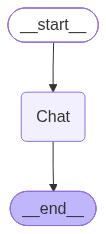

In [126]:
thread_id = 1
graph = StateGraph(ChatState)

graph.add_node('Chat', Chat)

graph.add_edge(START, 'Chat')
graph.add_edge('Chat', END)

Chatbot = graph.compile(checkpointer=checkpointer)
Chatbot

In [127]:
while True:

    user_message = input("Enter Text: ")
    print("You: ", user_message)

    if user_message.strip().lower() in ['exit','leaving','bye','break']:
        print("Have a good day bye!")
        break

    res =  Chatbot.invoke({"messages": [HumanMessage(content=user_message)]},
            {"configurable":{"thread_id":thread_id}})
    print('AI: ', res["messages"][-1].content)
   


You:  Hi, My name is Namita.
AI:  Hi Namita, it's nice to meet you! How can I help you today?
You:  WHat is my name?
AI:  Your name is Namita.
You:  okay and what is 100+50
AI:  100 + 50 = 150
You:  and whats 60 added to it?
AI:  If you add 60 to 150, you get **210**.
You:  50 added to it and 100 minus is?
AI:  Let's break that down:

*   **50 added to it:** "It" refers to the previous result, which was 210. So, 210 + 50 = **260**.
*   **and 100 minus is?:** This means 100 subtracted from the result of the addition. So, 260 - 100 = **160**.

Therefore, 50 added to 210 and then 100 minus is **160**.
You:  Okay, thanks
AI:  You're welcome, Namita! Is there anything else I can help you with today?
You:  nope, bye
AI:  Goodbye, Namita! Have a great day!
You:  bye
Have a good day bye!
